In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- 1. Wireless Environment Parameters ---
B_HZ = 1e6              # 1 MHz
N0_DBM_HZ = -174        # Noise density
P_TX_CLIENT_DBM = 24    # Uplink Power
P_TX_SERVER_DBM = 46    # Downlink Power (Server)
Q_BITS = 16             # 16-bit quantization
RADIUS_KM = 0.5         # 500m
DEVICE_GFLOPS = 2.0     # Average edge device speed (2 Billion operations/sec)

In [3]:
# --- 2. Model Architectures ---

class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

In [4]:
# --- 3. Wireless Channel ---

def get_round_delays(model, task):
    # --- 3.1. Wireless Environment Setup ---
    # Total Bandwidth B = 1MHz
    B_total = B_HZ 
    K = 30 # Number of devices
    
    # OFDMA Uplink: Each device gets a sub-channel Bk
    Bk = B_total / K 
    
    # Noise calculation (N0 * Bandwidth)
    # For Uplink: Noise power in sub-channel Bk
    noise_w_up = 10**(((N0_DBM_HZ + 10 * np.log10(Bk)) - 30) / 10)
    # For Downlink: Noise power in total bandwidth B
    noise_w_down = 10**(((N0_DBM_HZ + 10 * np.log10(B_total)) - 30) / 10)

    # Path Loss & Distances
    r_km = RADIUS_KM * np.sqrt(np.random.rand(K)) 
    path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
    
    # Payload Size (N * q)
    num_params = sum(p.numel() for p in model.parameters())
    payload_bits = num_params * Q_BITS

    # --- 3.2. Downlink Calculation (Equation 5) ---
    # Downlink SNR (gamma) is determined by the device with the worst channel gain
    p_rx_dbm_down = P_TX_SERVER_DBM - path_loss_db
    p_rx_w_down = 10**((p_rx_dbm_down - 30) / 10)
    
    gamma_down = np.min(p_rx_w_down / noise_w_down) # Minimum SNR among devices
    r_downlink = B_total * np.log2(1 + gamma_down)  # Achievable rate r
    d_down = payload_bits / r_downlink

    # --- 3.3. Uplink Calculation (Equation 4) ---
    # Achievable rate r_k for each device k using sub-channel Bk
    p_rx_dbm_up = P_TX_CLIENT_DBM - path_loss_db
    p_rx_w_up = 10**((p_rx_dbm_up - 30) / 10)
    
    gamma_up = p_rx_w_up / noise_w_up         # SNR gamma_k for each device
    rk_uplink = Bk * np.log2(1 + gamma_up)    # Achievable rate r_k
    
    # Total Uplink delay is the time until the last device k finishes
    d_up = np.max(payload_bits / rk_uplink)

    # --- 3.4. Computation Delay ---
    flops_per_img = 6000 if task == 'SVM' else 15_000_000
    num_samples = 330 if task == 'SVM' else 2000
    t_comp = (num_samples * flops_per_img) / (DEVICE_GFLOPS * 1e9)

    return d_down, t_comp, d_up

In [5]:
# --- 4. Data Preparation ---

def get_datasets(task='CNN'):
    if task == 'SVM':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        # Filter classes 0 (airplane) and 1 (automobile)
        train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
        test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
        # 15 devices get only airplanes, 15 get only automobiles (330 samples each)
        airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
        autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
        device_data = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                      [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
        return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001

    else: # CNN Task
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        
        # Pathological Non-IID: Sort by label, 60 shards, 2 per client
        indices = np.argsort(train_set.targets.numpy())
        shards = [indices[i*1000 : (i+1)*1000] for i in range(60)]
        device_data = [Subset(train_set, np.concatenate((shards[i*2], shards[i*2+1]))) for i in range(30)]
        
        return device_data, test_set, CNNModel(), 0.005

In [6]:
def get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho):
    """
    Implements Theorem 1 with safeguards for baseline cases (rho=0 or 1).
    """
    n_total = sum(n_k_list)
    grad_norms = np.array(grad_norms) + 1e-12 
    T_u_list = np.array(T_u_list)

    # Shortcut for Channel-aware (rho=0) 
    if rho == 0:
        # Probability is inversely proportional to sqrt of latency
        p = 1.0 / np.sqrt(T_u_list + 1e-12)
        return p / np.sum(p)

    # Shortcut for Importance-aware (rho=1) [cite: 504]
    if rho == 1:
        # Probability is proportional to (n_k/n) * ||g_k||
        p = (np.array(n_k_list) / n_total) * grad_norms
        return p / np.sum(p)

    # Bisection search for Proposed Policy (0 < rho < 1) [cite: 322, 325]
    def compute_p_star(lam):
        denom = (1 - rho) * T_u_list + lam
        # Theorem 1: p_k is proportional to (n_k/n)*||g_k|| * sqrt(rho/denom)
        p = (np.array(n_k_list) / n_total) * grad_norms * np.sqrt(rho / np.maximum(denom, 1e-15))
        return p

    # Find search bounds for lambda
    # denom must be > 0, so lam > -(1-rho)*T_u_min
    low = -np.min((1 - rho) * T_u_list) + 1e-12
    high = 1e6
    
    for _ in range(100):
        mid = (low + high) / 2
        p_temp = compute_p_star(mid)
        if np.sum(p_temp) > 1:
            low = mid
        else:
            high = mid
            
    final_p = compute_p_star(high)
    return final_p / np.sum(final_p)

In [14]:
def run_importance_aware_fl(task='SVM', rounds=100, rho=5e-6):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    n_k_list = [len(d) for d in device_data]
    n_total = sum(n_k_list)
    lmbda = 0.01 
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30)) 
    
    history = {'acc': [], 'time': []}
    cumulative_time = 0

    print(f"\n--- Simulation: {task} | 30 Clients | {rounds} Rounds ---")

    for r in range(rounds):
        # Step 1: Wireless Environment
        path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
        
        noise_up_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
        p_rx_up_w = 10**(((P_TX_CLIENT_DBM - path_loss_db) - 30) / 10)
        gamma_up = p_rx_up_w / noise_up_w
        
        noise_down_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
        p_rx_down_w = 10**(((P_TX_SERVER_DBM - path_loss_db) - 30) / 10)
        gamma_down_min = np.min(p_rx_down_w / noise_down_w) 
        
        num_params = sum(p.numel() for p in global_model.parameters())
        payload_bits = num_params * Q_BITS
        T_u_list = payload_bits / (B_HZ * np.log2(1 + gamma_up))

        # Steps 2 & 3: Importance Evaluation
        grad_norms = []
        client_gradients = []
        for i in range(30):
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            loader = DataLoader(device_data[i], batch_size=len(device_data[i]))
            data, target = next(iter(loader))
            local_model.zero_grad()
            output = local_model(data).squeeze()
            if task == 'SVM':
                target_svm = (target.float() * 2) - 1 
                loss = 0.5 * torch.mean(torch.clamp(1 - target_svm * output, min=0)) + (lmbda / 2.0) * sum(p.pow(2).sum() for p in local_model.parameters())
            else:
                target_oh = torch.nn.functional.one_hot(target, num_classes=10).float()
                loss = 0.5 * torch.nn.functional.mse_loss(output, target_oh, reduction='mean')
            loss.backward()
            grads = [p.grad.detach().clone() for p in local_model.parameters()]
            grad_norms.append(torch.norm(torch.cat([g.view(-1) for g in grads])).item())
            client_gradients.append(grads)

        # Step 4: Selection
        p_star = get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho)
        selected_idx = np.random.choice(range(30), p=p_star)

        # Step 5: Latency [cite: 279]
        t_broadcast = payload_bits / (B_HZ * np.log2(1 + gamma_down_min)) 
        t_comp_max = (max(n_k_list) * (6000 if task=='SVM' else 15e6)) / (DEVICE_GFLOPS * 1e9)
        cumulative_time += (t_broadcast + t_comp_max + T_u_list[selected_idx])

        # Step 6: Update [cite: 209]
        with torch.no_grad():
            scale = n_k_list[selected_idx] / (n_total * p_star[selected_idx])
            for p_global, g_local in zip(global_model.parameters(), client_gradients[selected_idx]):
                p_global -= lr * (scale * g_local)

        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                pred = torch.sign(output.squeeze()) if task == 'SVM' else output.argmax(1)
                labels = (target.float()*2-1) if task == 'SVM' else target
                correct += (pred == labels).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        print(f"Round {r+1:02d} | Acc: {acc:.2f}% | Sim Time: {cumulative_time:.2f}s")

    return history

In [15]:
def run_full_comparison(task='SVM', rounds=50):
    """
    Executes all scheduling policies for a specific task and plots the results.
    """
    # Set default rounds and rhos based on the paper's experiment settings
    if task == 'SVM':
        # Paper uses these rho values for SVM comparison [cite: 507]
        rhos = {0: 'Channel-aware', 
                1: 'Importance-aware', 
                5e-6: 'Proposed (5e-6)', 
                5e-4: 'Proposed (5e-4)'}
        x_label = "Training Time (seconds)"
        time_scale = 1 # Seconds
    else: # CNN
        # Paper uses these rho values for CNN comparison [cite: 590]
        rhos = {0: 'Channel-aware', 
                1: 'Importance-aware', 
                5e-3: 'Proposed (5e-3)'}
        x_label = "Training Time (minutes)"
        time_scale = 60 # Minutes
    
    results = {}
    
    print(f"--- Starting {task} Comparison for {rounds} Rounds ---")
    for rho, label in rhos.items():
        print(f"Running {label} (rho={rho})...")
        # Ensure your model/optimizer is reset inside run_importance_aware_fl for each policy
        results[label] = run_importance_aware_fl(task=task, rounds=rounds, rho=rho)

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    for label, hist in results.items():
        # Convert time to the appropriate scale (seconds or minutes) [cite: 592]
        plt.plot(np.array(hist['time']) / time_scale, hist['acc'], label=label)
    
    plt.title(f"Performance Comparison: {task} Model")
    plt.xlabel(x_label)
    plt.ylabel("Test Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# To run SVM comparison:
# run_full_comparison(task='SVM')

# To run CNN comparison:
# run_full_comparison(task='CNN')

In [16]:
run_importance_aware_fl(task='CNN', rounds=10)


--- Simulation: CNN | 30 Clients | 10 Rounds ---
Round 01 | Acc: 10.31% | Sim Time: 16.28s
Round 02 | Acc: 10.31% | Sim Time: 32.56s
Round 03 | Acc: 10.33% | Sim Time: 48.84s
Round 04 | Acc: 10.30% | Sim Time: 65.11s
Round 05 | Acc: 10.29% | Sim Time: 81.39s
Round 06 | Acc: 10.30% | Sim Time: 97.67s
Round 07 | Acc: 10.31% | Sim Time: 113.95s
Round 08 | Acc: 10.31% | Sim Time: 130.23s
Round 09 | Acc: 10.31% | Sim Time: 146.51s
Round 10 | Acc: 10.31% | Sim Time: 162.79s


{'acc': [10.31, 10.31, 10.33, 10.3, 10.29, 10.3, 10.31, 10.31, 10.31, 10.31],
 'time': [np.float64(16.27869603645085),
  np.float64(32.5573920729017),
  np.float64(48.836088109352545),
  np.float64(65.1147841458034),
  np.float64(81.39348018225425),
  np.float64(97.6721762187051),
  np.float64(113.95087225515596),
  np.float64(130.2295682916068),
  np.float64(146.50826432805763),
  np.float64(162.78696036450847)]}

--- Starting CNN Comparison for 1120 Rounds ---
Running Channel-aware (rho=0)...

--- Simulation: CNN | 30 Clients | 1120 Rounds ---
Round 01 | Acc: 11.90% | Sim Time: 16.44s
Round 02 | Acc: 11.85% | Sim Time: 33.38s
Round 03 | Acc: 12.20% | Sim Time: 50.06s
Round 04 | Acc: 13.06% | Sim Time: 66.40s
Round 05 | Acc: 12.93% | Sim Time: 82.70s
Round 06 | Acc: 13.85% | Sim Time: 99.02s
Round 07 | Acc: 13.73% | Sim Time: 115.68s
Round 08 | Acc: 14.35% | Sim Time: 132.49s
Round 09 | Acc: 14.64% | Sim Time: 149.30s
Round 10 | Acc: 14.56% | Sim Time: 166.23s
Round 11 | Acc: 14.37% | Sim Time: 183.14s
Round 12 | Acc: 14.05% | Sim Time: 199.91s
Round 13 | Acc: 14.81% | Sim Time: 216.24s
Round 14 | Acc: 14.84% | Sim Time: 233.14s
Round 15 | Acc: 15.46% | Sim Time: 249.48s
Round 16 | Acc: 15.32% | Sim Time: 265.84s
Round 17 | Acc: 15.37% | Sim Time: 282.14s
Round 18 | Acc: 15.40% | Sim Time: 298.84s
Round 19 | Acc: 15.38% | Sim Time: 315.14s
Round 20 | Acc: 15.68% | Sim Time: 331.47s
Round 21 | Ac

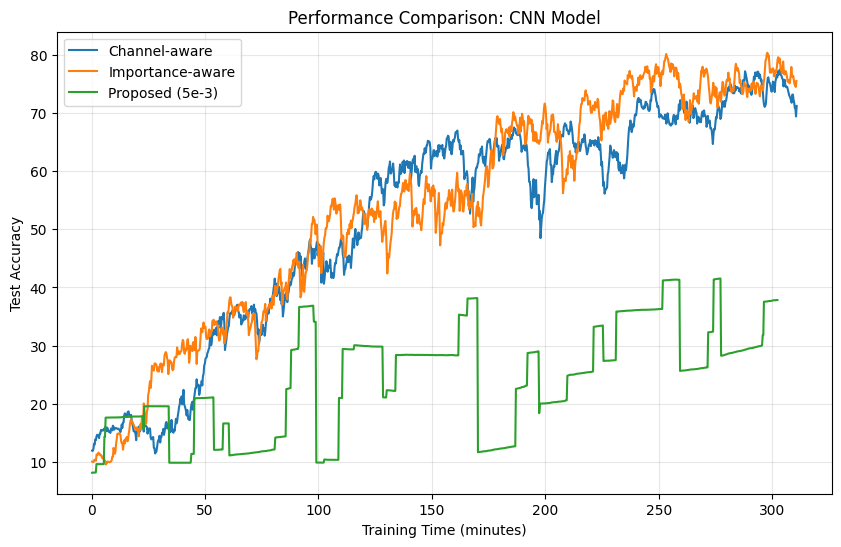

In [17]:
run_full_comparison(task='CNN', rounds=1120)